# 📘 Análisis de pérdidas del modelo de hielo marino

Este notebook carga el archivo `models_*.nc`, reconstruye los términos del loss por *epoch* y realiza visualizaciones y tablas para entender cómo se combinaron los términos del coste durante el entrenamiento.

In [6]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.figsize'] = (10, 6)

## 1️⃣ Cargar el archivo models

Modifica la ruta si es necesario.

In [7]:
folder = "/perm/dnk8355/outputs_training_v2_dec25"
models_file = os.path.join(folder, "models_1april2024_31march2025_with_angle_bg_emis07_with_losses.nc")

ds = xr.open_dataset(models_file)
ds

<xarray.Dataset>
Dimensions:                          (one: 1, alphas: 2, sensor: 1, area: 2,
                                      in: 5, width: 7, out: 2, channel: 4,
                                      sensors: 1, biases: 2, epoch: 8,
                                      batch: 2474)
Coordinates:
  * one                              (one) int64 1
  * alphas                           (alphas) int64 0 1
  * sensor                           (sensor) int64 0
  * area                             (area) int64 0 1
  * in                               (in) int64 0 1 2 3 4
  * width                            (width) int64 0 1 2 3 4 5 6
  * out                              (out) int64 0 1
  * channel                          (channel) int64 0 1 2 3
  * sensors                          (sensors) int64 0
  * biases                           (biases) int64 0 1
  * epoch                            (epoch) int64 0 1 2 3 4 5 6 7
  * batch                            (batch) int64 0 1 2 3 ... 2471 2472 2473
Data variables: (12/42)
    nsensors                         (one) int64 ...
    nfields_float                    (one) int64 ...
    nfields_int                      (one) int64 ...
    nchannels                        (one) int64 ...
    nbiases                          (one) int64 ...
    nprop_grid                       (one) int64 ...
    ...                               ...
    loss_per_batch                   (epoch, batch) float64 ...
    loss_channel_weighted_per_batch  (epoch, batch) float64 ...
    seaice_loss_per_batch            (epoch, batch) float64 ...
    tsfc_loss_per_batch              (epoch, batch) float64 ...
    emis_loss_per_batch              (epoch, batch) float64 ...
    bias_loss_per_batch              (epoch, batch) float64 ...

## 2️⃣ Reconstruir los losses por epoch

Usa tanto los valores por batch como los valores agregados que ya guarda Keras.

In [8]:
def reconstruct_epoch_losses(ds):
    epoch_losses = {}

    # Loss principal total por epoch
    epoch_losses["loss_epoch"] = ds["loss"].values

    # Componentes del loss por epoch
    for comp in ["seaice_loss", "tsfc_loss", "emis_loss", "bias_loss"]:
        epoch_losses[f"{comp}_epoch"] = ds[comp].values

    # Extra: reconstruimos el loss de observación "obs_loss"
    # A partir de total_loss = obs_loss + regularizaciones
    epoch_losses["obs_loss_epoch"] = (
        ds["loss"].values
        - ds["seaice_loss"].values
        - ds["tsfc_loss"].values
        - ds["emis_loss"].values
        - ds["bias_loss"].values
    )

    return epoch_losses

epoch_losses = reconstruct_epoch_losses(ds)
epoch_losses

{'loss_epoch': array([1.13016963e+04, 5.58322601e+01, 3.46877098e+01, 1.67075958e+01,
        8.84962368e+00, 5.91117191e+00, 4.60600042e+00, 3.91641760e+00]),
 'seaice_loss_epoch': array([0.26378042, 0.53089827, 0.57938409, 0.46038538, 0.34986198,
        0.29247874, 0.26433864, 0.24980827]),
 'tsfc_loss_epoch': array([6.33780132e-07, 1.02957188e-06, 1.20748632e-06, 1.38609050e-06,
        1.56704675e-06, 1.67603059e-06, 1.76812136e-06, 1.81547614e-06]),
 'emis_loss_epoch': array([1.12018662e+04, 4.31501912e-03, 1.37568384e-01, 1.46986544e-01,
        5.52373417e-02, 2.19944119e-02, 1.02892388e-02, 4.21618856e-03]),
 'bias_loss_epoch': array([1.68718896e-06, 1.14173172e-05, 2.69055727e-05, 3.99303281e-05,
        4.63657598e-05, 5.03962401e-05, 5.36955449e-05, 5.67098068e-05]),
 'obs_loss_epoch': array([99.56629539, 55.29703439, 33.97072922, 16.10018258,  8.44447643,
         5.59664669,  4.33131708,  3.66233462])}

## 3️⃣ Crear tabla resumen

Tabla con un renglón por epoch y columnas para cada término del loss.

In [9]:
def make_epoch_table(epoch_losses):
    df = pd.DataFrame({
        "obs_loss": epoch_losses["obs_loss_epoch"],
        "seaice_loss": epoch_losses["seaice_loss_epoch"],
        "tsfc_loss": epoch_losses["tsfc_loss_epoch"],
        "emis_loss": epoch_losses["emis_loss_epoch"],
        "bias_loss": epoch_losses["bias_loss_epoch"],
        "total_loss": epoch_losses["loss_epoch"],
    })
    df.index.name = "epoch"
    return df

epoch_table = make_epoch_table(epoch_losses)
epoch_table

,obs_loss,seaice_loss,tsfc_loss,emis_loss,bias_loss,total_loss
epoch,,,,,,
0,99.566295,0.263780,6.337801e-07,11201.866211,0.000002,11301.696289
1,55.297034,0.530898,1.029572e-06,0.004315,0.000011,55.832260
2,33.970729,0.579384,1.207486e-06,0.137568,0.000027,34.687710
3,16.100183,0.460385,1.386091e-06,0.146987,0.000040,16.707596
4,8.444476,0.349862,1.567047e-06,0.055237,0.000046,8.849624
5,5.596647,0.292479,1.676031e-06,0.021994,0.000050,5.911172
6,4.331317,0.264339,1.768121e-06,0.010289,0.000054,4.606000
7,3.662335,0.249808,1.815476e-06,0.004216,0.000057,3.916418


## 4️⃣ Graficar evolución de cada término del loss por epoch

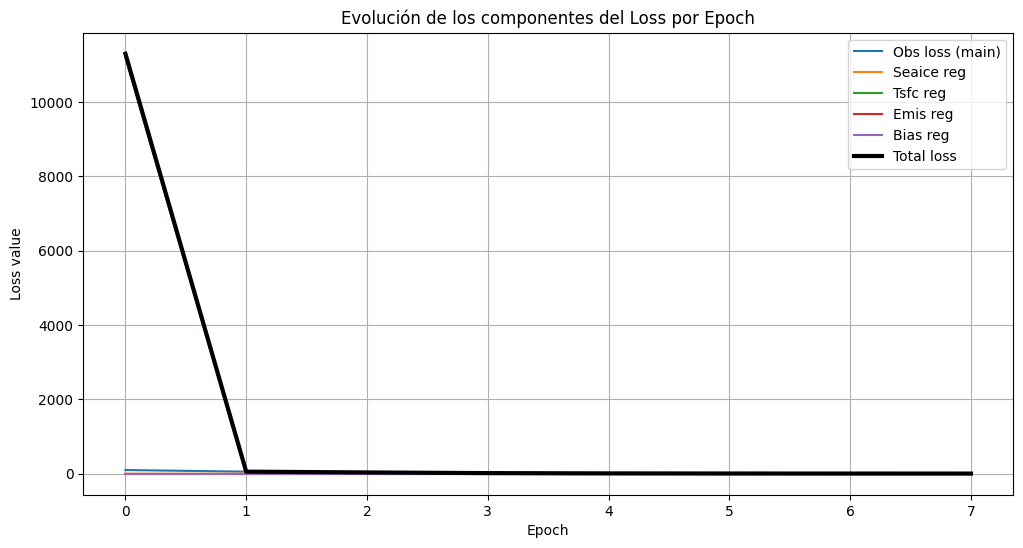

In [10]:
def plot_losses(epoch_losses):
    epochs = np.arange(len(epoch_losses["loss_epoch"]))

    plt.figure(figsize=(12, 6))
    plt.plot(epochs, epoch_losses["obs_loss_epoch"], label="Obs loss (main)")
    plt.plot(epochs, epoch_losses["seaice_loss_epoch"], label="Seaice reg")
    plt.plot(epochs, epoch_losses["tsfc_loss_epoch"], label="Tsfc reg")
    plt.plot(epochs, epoch_losses["emis_loss_epoch"], label="Emis reg")
    plt.plot(epochs, epoch_losses["bias_loss_epoch"], label="Bias reg")
    plt.plot(epochs, epoch_losses["loss_epoch"], label="Total loss", linewidth=3, color="black")

    plt.xlabel("Epoch")
    plt.ylabel("Loss value")
    plt.legend()
    plt.grid(True)
    plt.title("Evolución de los componentes del Loss por Epoch")
    plt.show()

plot_losses(epoch_losses)

## 5️⃣ (Opcional) Graficar el loss total por batch en cada epoch

In [11]:
def plot_batches(ds):
    loss_batch = ds["loss_per_batch"].values
    n_epochs, n_batches = loss_batch.shape

|    for e in range(n_epochs):
        plt.figure(figsize=(12,4))
        plt.plot(loss_batch[e,:])
        plt.title(f"Loss total por batch — Epoch {e}")
        plt.xlabel("Batch")
        plt.ylabel("Loss")
        plt.grid(True)
        plt.show()

plot_batches(ds)

SyntaxError: invalid syntax (215520902.py, line 5)